# Training, Benchmarking, and Threshold Calibration

**Purpose.** Make the model-development process reproducible without retraining large models every time this notebook is opened.

**Expected result.** A map of training scripts, saved protocols, benchmark candidates, selected architectures, and calibrated thresholds read from the promoted artifacts.

**Platform connection.** Training is an offline workflow. Only promoted artifacts and metadata are used by live inspection.

In [1]:
from pathlib import Path
import json
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import JSON, Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "ml").exists():
    raise RuntimeError("Run this notebook from the repository root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

def locate_mvtec_root() -> Path:
    configured = os.getenv("MVTEC_DATASET_ROOT")
    candidates = [
        Path(configured).expanduser() if configured else None,
        PROJECT_ROOT / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai-github" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection",
        PROJECT_ROOT.parent / "visioninspect-ai" / "data" / "raw" / "mvtec_anomaly_detection1",
    ]
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "MVTec AD was not found. Set MVTEC_DATASET_ROOT or place the dataset under "
        "data/raw/mvtec_anomaly_detection."
    )

DATASET_ROOT = locate_mvtec_root()
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def image_files(directory: Path) -> list[Path]:
    if not directory.exists():
        return []
    return sorted(path for path in directory.iterdir() if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def first_test_image(category: str, label: str) -> Path:
    paths = image_files(DATASET_ROOT / category / "test" / label)
    if not paths:
        raise FileNotFoundError(f"No {category}/{label} test image was found.")
    return paths[0]

def first_defect(category: str) -> tuple[str, Path]:
    test_root = DATASET_ROOT / category / "test"
    defect_dirs = sorted(path for path in test_root.iterdir() if path.is_dir() and path.name != "good")
    for directory in defect_dirs:
        paths = image_files(directory)
        if paths:
            return directory.name, paths[0]
    raise FileNotFoundError(f"No defective test image was found for {category}.")

def mask_path_for(category: str, label: str, image_path: Path) -> Path | None:
    if label == "good":
        return None
    candidate = DATASET_ROOT / category / "ground_truth" / label / f"{image_path.stem}_mask.png"
    return candidate if candidate.exists() else None

def read_rgb(path: Path) -> np.ndarray:
    image = cv2.imread(str(path))
    if image is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print(f"Project root: {PROJECT_ROOT}")
print(f"MVTec root:  {DATASET_ROOT}")

Project root: C:\Users\HP\Desktop\springboard\VisionInspectAI-team
MVTec root:  C:\Users\HP\Desktop\springboard\visioninspect-ai-github\data\raw\mvtec_anomaly_detection


In [2]:
script_rows = [
    ("train_category_models.py", "Train PaDiM and build portable normal profiles"),
    ("benchmark_category_models.py", "Compare current PaDiM, centered PaDiM, and PatchCore candidates"),
    ("promote_category_benchmarks.py", "Promote the strongest candidate to the model registry"),
    ("calibrate_category_thresholds.py", "Select detector thresholds on a calibration split and evaluate holdout behavior"),
    ("train_category_classifiers.py", "Train category-specific defect subtype classifiers"),
    ("train_finetuned_cnn_classifiers.py", "Train and export optional CNN subtype classifiers"),
    ("export_openvino.py", "Export available advanced checkpoints to OpenVINO"),
]
scripts_df = pd.DataFrame(script_rows, columns=["script", "responsibility"])
scripts_df["present"] = scripts_df["script"].map(lambda name: (PROJECT_ROOT / "scripts" / name).exists())
display(scripts_df)

,script,responsibility,present
0,train_category_models.py,Train PaDiM and build portable normal profiles,True
1,benchmark_category_models.py,"Compare current PaDiM, centered PaDiM, and Pat...",True
2,promote_category_benchmarks.py,Promote the strongest candidate to the model r...,True
3,calibrate_category_thresholds.py,Select detector thresholds on a calibration sp...,True
4,train_category_classifiers.py,Train category-specific defect subtype classif...,True
5,train_finetuned_cnn_classifiers.py,Train and export optional CNN subtype classifiers,True
6,export_openvino.py,Export available advanced checkpoints to OpenVINO,True


## Reproducible command sequence

```powershell
python scripts/train_category_models.py --categories cable --dataset-root <MVTEC_ROOT>
python scripts/benchmark_category_models.py --categories cable --dataset-root <MVTEC_ROOT>
python scripts/promote_category_benchmarks.py --categories cable
python scripts/calibrate_category_thresholds.py --categories cable --engine advanced --dataset-root <MVTEC_ROOT>
python scripts/train_category_classifiers.py --categories cable --dataset-root <MVTEC_ROOT>
python scripts/calibrate_category_thresholds.py --categories cable --engine baseline --dataset-root <MVTEC_ROOT>
python scripts/export_openvino.py
```

The training commands are intentionally shown rather than executed here. They can take hours, require GPU memory, and overwrite promoted model artifacts. This notebook reads the resulting evidence safely.

In [3]:
from ml.model_registry import SUPPORTED_CATEGORIES, category_model_spec

protocol_rows = []
benchmark_rows = []
for category in SUPPORTED_CATEGORIES:
    spec = category_model_spec(category)
    metadata = json.loads(spec.metadata_path.read_text(encoding="utf-8"))
    advanced = metadata.get("threshold_calibration", {})
    baseline = metadata.get("baseline_threshold_calibration", {})
    classifier = metadata.get("defect_classifier", {})
    protocol_rows.append(
        {
            "category": category,
            "selected_model": spec.model_kind,
            "advanced_threshold": advanced.get("threshold", spec.padim_score_threshold),
            "advanced_holdout_F1": advanced.get("holdout_f1"),
            "portable_threshold": baseline.get("threshold", spec.baseline_score_threshold),
            "portable_validation_F1": baseline.get("cv_f1", baseline.get("holdout_f1")),
            "subtype_macro_F1": classifier.get("macro_f1"),
            "subtype_protocol": classifier.get("evaluation", {}).get("protocol"),
        }
    )
    for candidate_name, values in metadata.get("benchmark_comparison", {}).items():
        benchmark_rows.append(
            {
                "category": category,
                "candidate": candidate_name,
                "image_AUROC": values.get("image_auroc"),
                "image_F1": values.get("image_f1"),
                "pixel_AUROC": values.get("pixel_auroc"),
                "pixel_F1": values.get("pixel_f1"),
            }
        )

protocol_df = pd.DataFrame(protocol_rows)
display(protocol_df.style.format({
    "advanced_threshold": "{:.4f}", "advanced_holdout_F1": "{:.4f}",
    "portable_threshold": "{:.4f}", "portable_validation_F1": "{:.4f}",
    "subtype_macro_F1": "{:.4f}",
}, na_rep="n/a"))

,category,selected_model,advanced_threshold,advanced_holdout_F1,portable_threshold,portable_validation_F1,subtype_macro_F1,subtype_protocol
0,bottle,padim,0.5001,n/a,0.0091,0.9764,0.8719,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
1,cable,patchcore,0.5137,0.9000,0.0415,0.8208,0.8529,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
2,capsule,padim,0.5009,0.9434,0.0082,0.8683,0.8250,stratified holdout validation; best epoch selected by macro F1
3,carpet,padim,0.6162,0.9217,0.0117,0.6222,0.9009,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
4,grid,padim,0.4871,0.9286,0.0168,0.6598,0.7742,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
5,hazelnut,patchcore,0.4815,0.9600,0.0635,0.8769,0.9295,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
6,leather,padim,0.5000,1.0000,0.0133,0.8606,0.9017,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
7,metal_nut,padim,0.5000,0.9706,0.0289,0.7771,0.9357,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
8,pill,padim,0.5235,0.9254,0.0261,0.6983,0.8828,stratified cross-validation for model selection; production classifier fitted on all labelled defect images
9,screw,patchcore,0.4163,0.9364,0.0175,0.8073,0.9233,stratified cross-validation for model selection; production classifier fitted on all labelled defect images


,category,candidate,image_AUROC,image_F1,pixel_AUROC,pixel_F1
0,cable,baseline,0.8774,0.8558,0.9683,0.4860
1,cable,padim_center_roi,0.9048,0.8617,0.9649,0.5282
2,cable,patchcore,0.9670,0.9167,0.9816,0.6156
3,grid,baseline,0.8864,0.9000,0.9583,0.3316
4,grid,padim_center_roi,0.9607,0.9381,0.9676,0.3710
5,grid,patchcore,0.9148,0.9057,0.9608,0.3545
6,hazelnut,baseline,0.8832,0.8767,0.9763,0.5267
7,hazelnut,padim_center_roi,0.9321,0.9178,0.9773,0.5787
8,hazelnut,patchcore,0.9961,0.9718,0.9880,0.6403
9,screw,baseline,0.8307,0.8845,0.9841,0.2641


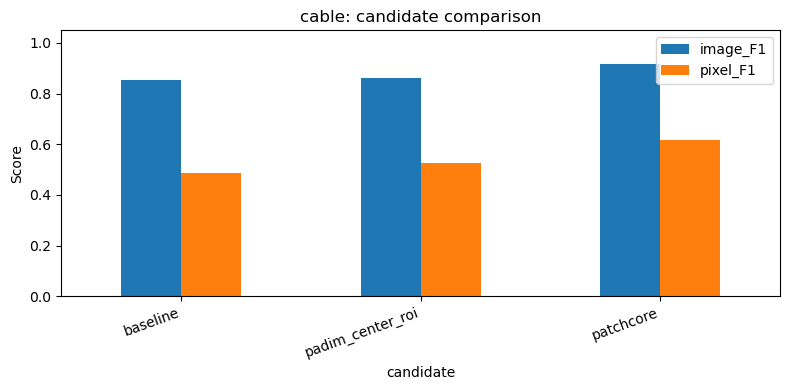

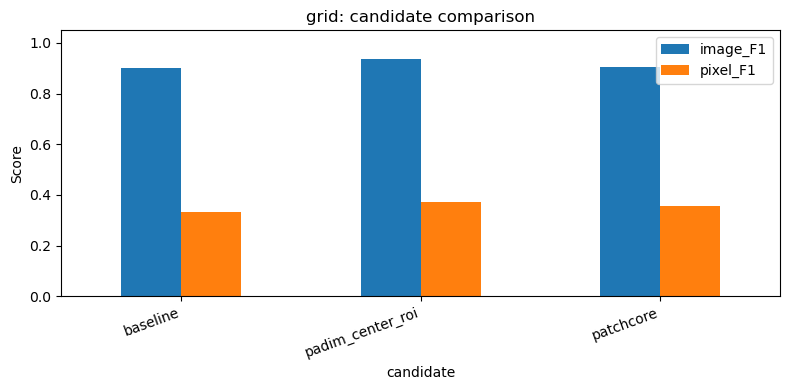

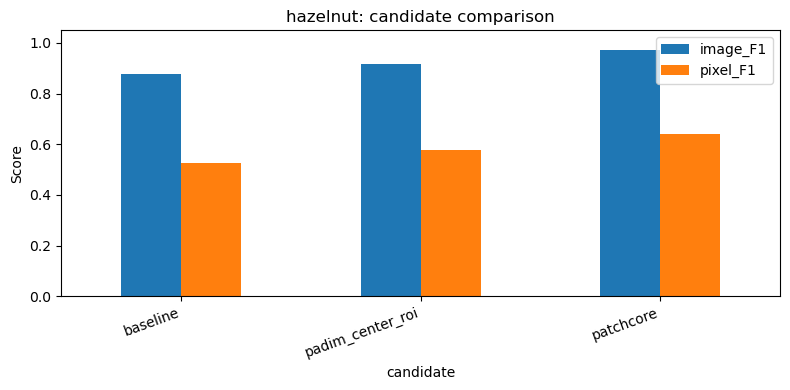

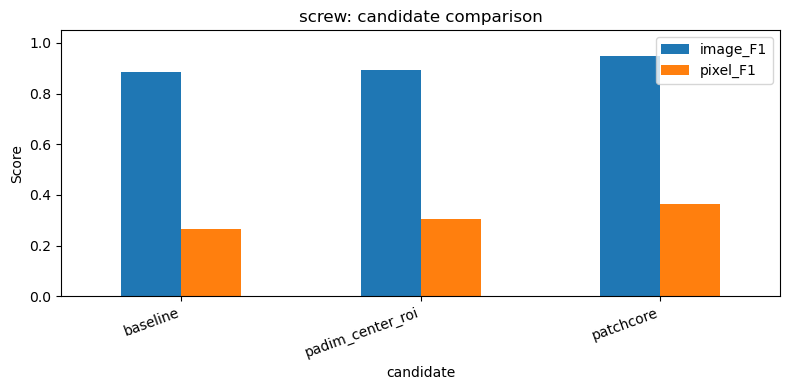

In [4]:
benchmark_df = pd.DataFrame(benchmark_rows)
if benchmark_df.empty:
    display(Markdown("No candidate benchmark comparisons are stored in the current metadata."))
else:
    display(benchmark_df.style.format({column: "{:.4f}" for column in ["image_AUROC", "image_F1", "pixel_AUROC", "pixel_F1"]}, na_rep="n/a"))
    for category in benchmark_df["category"].unique():
        category_df = benchmark_df[benchmark_df["category"] == category].set_index("candidate")
        category_df[["image_F1", "pixel_F1"]].plot(kind="bar", figsize=(8, 4), title=f"{category}: candidate comparison")
        plt.ylim(0, 1.05)
        plt.ylabel("Score")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.show()

In [5]:
cable_metadata = json.loads(category_model_spec("cable").metadata_path.read_text(encoding="utf-8"))
calibration_sections = {
    "advanced_detector": cable_metadata.get("threshold_calibration", {}),
    "portable_detector": cable_metadata.get("baseline_threshold_calibration", {}),
    "openvino_spatial_calibrator": cable_metadata.get("openvino_spatial_calibration", {}),
}
for name, values in calibration_sections.items():
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    compact = {key: value for key, value in values.items() if key not in {"defect_subtype_recall", "confusion_matrix", "fold_thresholds"}}
    display(pd.DataFrame([compact]))

### Advanced Detector

,model_kind,threshold,protocol,calibration_samples,holdout_samples,holdout_accuracy,holdout_precision,holdout_recall,holdout_f1,holdout_auroc
0,patchcore,0.513668,30% stratified development calibration; 70% st...,45,105,0.8857,0.9643,0.8438,0.9,0.9703


### Portable Detector

,threshold,protocol,folds,samples,cv_accuracy,cv_precision,cv_recall,cv_specificity,cv_balanced_accuracy,cv_f1,auroc,detector,localization,residual_threshold
0,0.041518,5-fold stratified balanced-threshold validatio...,5,150,0.7933,0.8765,0.7717,0.8276,0.7997,0.8208,0.8711,resnet18_normal_memory,opencv_normalized_residual,1.298446


### Openvino Spatial Calibrator

,detector,protocol,folds,samples,decision_threshold,accuracy,precision,recall,specificity,balanced_accuracy,f1,artifact
0,patchcore_openvino_spatial_calibrator,5-fold stratified out-of-fold evaluation on la...,5,150,0.5,0.96,0.9778,0.9565,0.9655,0.961,0.967,models/categories/cable/openvino_calibrator.npz


## Evaluation boundaries

- Advanced anomaly metrics come from the Anomalib MVTec evaluation pipeline.
- Current threshold calibration uses a stratified development split: 30% selects the threshold and 70% measures holdout performance.
- Some older portable metadata records a 5-fold protocol. The table reports the protocol stored with each artifact rather than pretending every artifact used the same experiment.
- Subtype classification uses labels from MVTec defect folders. It is a project-specific classification task, separate from the official MVTec Good/Defective benchmark.
- Training artifacts are promoted only after benchmark comparison; the live registry should never point at a temporary candidate by accident.

## What this demonstrates

Training, evaluation, calibration, promotion, and deployment are distinct stages. The notebook preserves that separation and reports recorded evidence without silently retraining or replacing production artifacts.